In [1]:
import numpy as np
import pandas as pd
import nltk
import re
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/Restaurant_Reviews.tsv'

try:
    data = pd.read_csv(path, delimiter='\t', quoting=3)
    print("Dataset loaded successfully!")
    print(f"Total reviews found: {len(data)}")
    print(data.head())
except Exception as e:
    print(f"Error: Could not find the file at {path}. Check your Drive folder.")
    print(f"Details: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Total reviews found: 1000
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


In [4]:
# Load the dataset
try:
    data = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)
    print("Dataset loaded successfully!")
    print(data.head())
except FileNotFoundError:
    print("Error: 'Restaurant_Reviews.tsv' not found. Please check the file path.")

Dataset loaded successfully!
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


In [5]:
corpus = []
ps = PorterStemmer()
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')

for i in range(0, 1000):
    review = re.sub('[^a-zA-Z]', ' ', data['Review'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in set(all_stopwords)]
    review = ' '.join(review)
    corpus.append(review)

print("Corpus created successfully!")

Corpus created successfully!


In [6]:
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

classifier = MultinomialNB()
classifier.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


Accuracy Score: 75.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75        96
           1       0.79      0.71      0.75       104

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



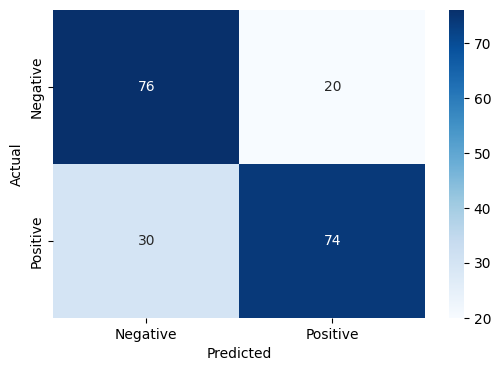

In [7]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [8]:
def predict_sentiment(sample_review):
    sample_review = re.sub('[^a-zA-Z]', ' ', sample_review)
    sample_review = sample_review.lower()
    sample_review = sample_review.split()
    sample_review = [ps.stem(word) for word in sample_review if not word in set(all_stopwords)]
    sample_review = ' '.join(sample_review)

    temp = cv.transform([sample_review]).toarray()
    prediction = classifier.predict(temp)
    return prediction[0]

user_input = "The atmosphere was great, but the food was not good."
result = predict_sentiment(user_input)
print(f"Review: {user_input}")
print("Result:", "POSITIVE" if result == 1 else "NEGATIVE")

Review: The atmosphere was great, but the food was not good.
Result: POSITIVE
